In [1]:
import torch
from torch import nn
from torch.nn import functional as f
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from torchmetrics.classification import Accuracy, Recall


In [3]:
import random
import os
import numpy as np
import torch
from tensorflow import keras

def set_seed(seed=42):
    # 1. 固定 Python 內建的隨機性
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. 固定 NumPy 的隨機性
    np.random.seed(seed)
    keras.utils.set_random_seed(seed)

set_seed(616) 
print("ok")

ok


In [66]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv')
#df.head()

df = df.drop(['id', 'Unnamed: 32'], axis=1)

mapping = {"M": 1, "B": 0}
df["diagnosis"] = df["diagnosis"].map(mapping)
#print(df.head())

print(df['diagnosis'].value_counts())

x = df.drop(columns = "diagnosis").values
y = df["diagnosis"].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=621)

m_scaler = MinMaxScaler()

x_train = m_scaler.fit_transform(x_train)
x_test = m_scaler.transform(x_test)

x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

x_1 = x[y == 1]
x_1 = m_scaler.transform(x_1)
x_1 = torch.tensor(x_1, dtype=torch.float32)

x_0 = x[y == 0]
x_0 = m_scaler.transform(x_0)
x_0 = torch.tensor(x_0, dtype=torch.float32)

diagnosis
0    357
1    212
Name: count, dtype: int64


In [61]:
type(x)

numpy.ndarray

In [54]:
class VAE(nn.Module):

    def __init__(self, input_dim=30, hidden_dim=32, latent_dim=2):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = f.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-20.0, max=20.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = f.relu(self.fc2(z))
        return f.sigmoid(self.fc3(h)) 

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

def vae_loss(recon_x, x, mu, logvar, kl_weight=0.01, beta = 10.0):
    x = torch.clamp(x, 1e-7, 1.0 - 1e-7)
    recon_x = torch.clamp(recon_x, 1e-7, 1.0 - 1e-7)
    
    recon_loss = f.binary_cross_entropy(recon_x, x, reduction="sum")
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + beta * (kl_weight * kl_loss)
    return total_loss, recon_loss, kl_loss

vae_dataset = TensorDataset(x_1)
vae_loader = DataLoader(vae_dataset, batch_size=64, shuffle=True)

VAE_model = VAE()
optimizer = Adam(VAE_model.parameters(), lr=0.001)

epochs = 400

for epoch in range(epochs):
    VAE_model.train()
    total_VAEloss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    
    kl_weight = min(1.0, epoch / 50.0) * 0.1 

    for batch in vae_loader:
        batch_data  = batch[0]
        
        optimizer.zero_grad()
        recon, mu, logvar = VAE_model(batch_data)
        assert batch_data.shape[1] == 30, f"輸入特徵維度錯誤: {batch_data.shape}"
        
        VAEloss, recon_loss, kl_loss = vae_loss(recon, batch_data, mu, logvar, kl_weight, beta = 20.0)

        VAEloss.backward()
        optimizer.step()
        
        batch_size = batch_data.size(0) 

        # 將 Loss 加總 (item() 已經是該 batch 的總和)
        total_VAEloss += VAEloss.item() 
        total_recon_loss += recon_loss.item()
        total_kl_loss += kl_loss.item()

    total_samples = len(x_1)
    avg_loss = total_VAEloss / total_samples
    avg_recon_loss = total_recon_loss / total_samples
    avg_kl_loss = total_kl_loss / total_samples

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f} | "
            f"Recon: {avg_recon_loss:.4f} | "
            f"KL: {avg_kl_loss:.4f} (wt: {kl_weight:.3f})"
        )


Epoch [1/400] Loss: 21.3878 | Recon: 21.3878 | KL: 0.0004 (wt: 0.000)
Epoch [10/400] Loss: 19.6272 | Recon: 19.6261 | KL: 0.0031 (wt: 0.018)
Epoch [20/400] Loss: 18.3872 | Recon: 18.3680 | KL: 0.0252 (wt: 0.038)
Epoch [30/400] Loss: 18.1220 | Recon: 18.0826 | KL: 0.0339 (wt: 0.058)
Epoch [40/400] Loss: 18.0636 | Recon: 18.0092 | KL: 0.0348 (wt: 0.078)
Epoch [50/400] Loss: 17.9970 | Recon: 17.9360 | KL: 0.0311 (wt: 0.098)
Epoch [60/400] Loss: 17.9377 | Recon: 17.8803 | KL: 0.0287 (wt: 0.100)
Epoch [70/400] Loss: 17.8684 | Recon: 17.8119 | KL: 0.0282 (wt: 0.100)
Epoch [80/400] Loss: 17.8068 | Recon: 17.7513 | KL: 0.0277 (wt: 0.100)
Epoch [90/400] Loss: 17.7416 | Recon: 17.6843 | KL: 0.0287 (wt: 0.100)
Epoch [100/400] Loss: 17.6569 | Recon: 17.5979 | KL: 0.0295 (wt: 0.100)
Epoch [110/400] Loss: 17.5903 | Recon: 17.5299 | KL: 0.0302 (wt: 0.100)
Epoch [120/400] Loss: 17.5422 | Recon: 17.4803 | KL: 0.0309 (wt: 0.100)
Epoch [130/400] Loss: 17.4947 | Recon: 17.4308 | KL: 0.0319 (wt: 0.100)
Epo

In [7]:
def sampling_fn(batch_size = 80):
    VAE_model.eval()
    batch_size = batch_size
    latent_dim = 2

    tensor = torch.randn(batch_size, latent_dim)
    y_tensor = torch.zeros(batch_size).view(-1, 1)

    new_data = VAE_model.decode(tensor).detach()

    x_train_sampling = torch.cat((x_train, new_data), dim=0)
    y_train_sampling = torch.cat((y_train, y_tensor), dim=0)

    perm_with_sampling = torch.randperm(x_train_sampling.size(0))
    x_train_sampling = x_train_sampling[perm_with_sampling]
    y_train_sampling = y_train_sampling[perm_with_sampling]

    return x_train_sampling, y_train_sampling

print("ok")

ok


In [14]:
def recon_error_fn(x, y):

    VAE_model.eval()

    with torch.no_grad():

        mu, _ = VAE_model.encode(x)
        x_hat = VAE_model.decode(mu)
        
        recon_error = torch.abs(x - x_hat)
        x_augmented = torch.cat((x, recon_error), dim=1) 

    perm = torch.randperm(x_augmented.size(0))
    x_train_recon = x_augmented[perm]
    y_train_recon = y[perm]

    return x_train_recon, y_train_recon
print("ok")


ok


In [58]:
# 檢查 x 是否存在於當前的命名空間
if 'x' in locals():
    print(f"警告：變數 'x' 已存在，內容為: {type(x)}")
else:
    print("變數 'x' 未定義，這很好，您沒用到污染變數。")

# 檢查您程式碼中是否有任何 x 的誤用
# 您的程式碼其實沒用到 'x'，但若您之前的環境有全域變數 'x'，
# 這不會影響訓練，除非您在函數內不小心引用了它。
print(x)

警告：變數 'x' 已存在，內容為: <class 'numpy.ndarray'>
[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]


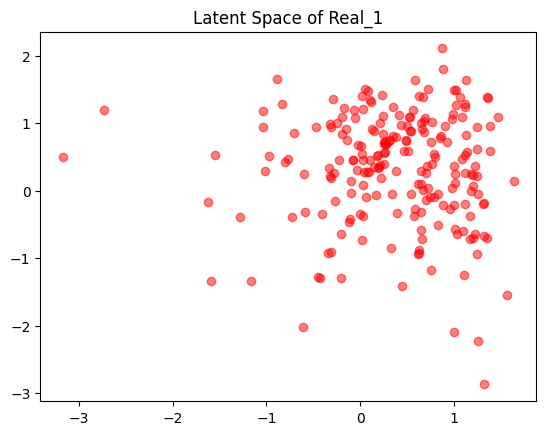

In [55]:
# 提取訓練集 Real_1 的潛空間分佈
mu_1, _ = VAE_model.encode(x_1)
# 畫出 mu 的散點圖
plt.scatter(mu_1[:, 0].detach(), mu_1[:, 1].detach(), c='red', alpha=0.5)
plt.title("Latent Space of Real_1")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


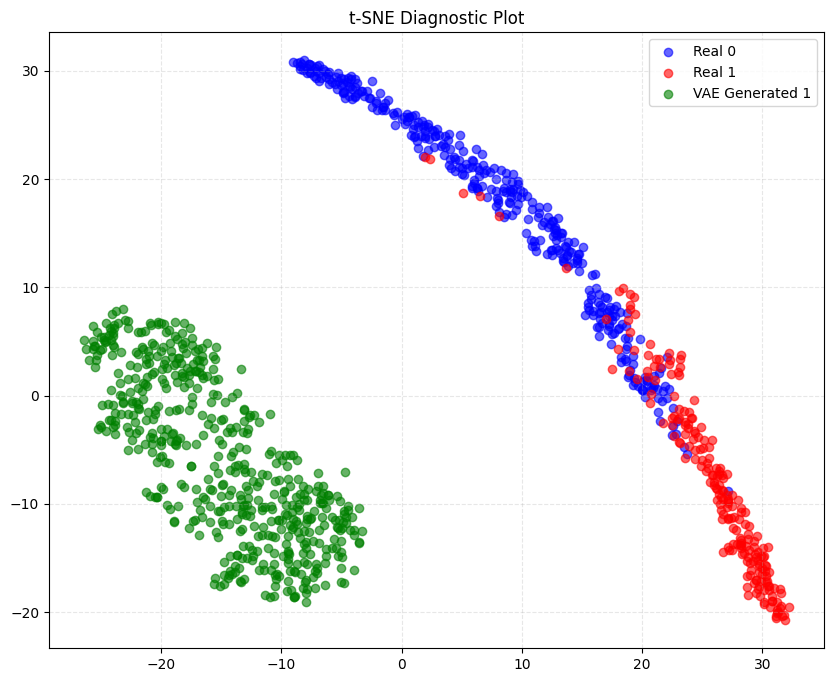

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

X_0 = x[y == 0]
X_1 = x[y == 1]
X_vae_1, _ = sampling_fn(80)
X = np.concatenate([X_0, X_1, X_vae_1], axis=0)

y = np.concatenate(
    [
        np.zeros(len(X_0)),
        np.ones(len(X_1)),
        np.ones(len(X_vae_1)) * 2,  
    ]
)


tsne = TSNE(n_components=2, perplexity=55, n_iter=1000, random_state=42)
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
colors = ["blue", "red", "green"]
labels = ["Real 0", "Real 1", "VAE Generated 1"]

for i in range(3):
    idx = y == i
    plt.scatter(
        X_embedded[idx, 0],
        X_embedded[idx, 1],
        c=colors[i],
        label=labels[i],
        alpha=0.6,
    )
plt.grid(True, linestyle='--', alpha=0.3)

plt.legend()
plt.title("t-SNE Diagnostic Plot")
plt.savefig("tsne_diagnostic_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [71]:
def get_recon_error(x):
    
    VAE_model.eval()

    with torch.no_grad():

        mu, _ = VAE_model.encode(x)
        x_hat = VAE_model.decode(mu)
        
        recon_error = torch.abs(x - x_hat)
    
    return recon_error

In [ ]:
def get_mu(x):
    VAE_model.eval()

    with torch.no_grad():
        mu, _ = VAE_model.enco

torch.Size([357, 30])


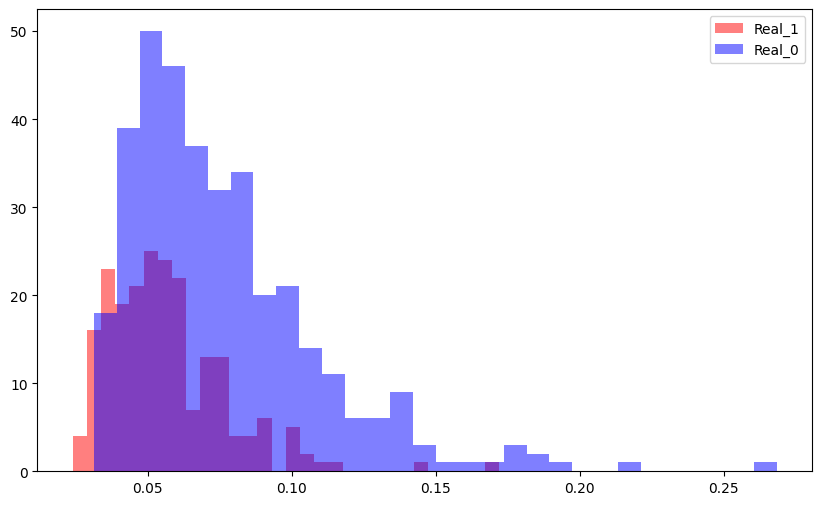

In [72]:
error_0 = get_recon_error(x_0)
error_1 = get_recon_error(x_1)

print(error_0.shape)
# 將 30 維誤差取平均，變成 (N,) 的一維向量
error_1_avg = error_1.mean(dim=1)
error_0_avg = error_0.mean(dim=1)

plt.figure(figsize=(10, 6))
# 現在只畫兩個數據集 (Real_1 和 Real_0)
plt.hist(error_1_avg, bins=30, alpha=0.5, label='Real_1', color='red')
plt.hist(error_0_avg, bins=30, alpha=0.5, label='Real_0', color='blue')
plt.legend()
plt.show()

In [15]:
class ResBlock(nn.Module):
    def __init__(self, features = 512, bottleneck_features = 64):
        super().__init__()

        self.bn1 = nn.BatchNorm1d(features)
        self.fnc1 = nn.Linear(features, bottleneck_features)
        
        self.bn2 = nn.BatchNorm1d(bottleneck_features)
        self.fnc2 = nn.Linear(bottleneck_features, bottleneck_features)

        self.bn3 = nn.BatchNorm1d(bottleneck_features)
        self.fnc3 = nn.Linear(bottleneck_features, features)
        
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        out = f.relu(self.bn1(x))
        out = self.dropout(self.fnc1(out))
        
        out = f.relu(self.bn2(out))
        out = self.fnc2(out)
        
        out = f.relu(self.bn3(out))
        out = self.fnc3(out)
        
        return x + out

class BranchBlock(nn.Module):
    def __init__(self, features = 512, depth = 3):
        super().__init__()
        self.res_layers = nn.ModuleList([
            ResBlock(features = features) for _ in range(depth)
        ])

    def forward(self, x):
        for layer in self.res_layers:
            x = layer(x)
        return x
class ElementWeight(nn.Module):
    def __init__(self, features = 512):
        super().__init__()
        self.fnc1 = nn.Linear(features, features)

    def forward(self, x):
        weights = torch.sigmoid(self.fnc1(x))

        return x * weights

class Detection_model(nn.Module):
    def __init__(self,dim = 60, num_resBlocks = 5, num_branchs = 5):
        super().__init__()
        self.input = nn.Linear(dim, 512)
        self.bn_in = nn.BatchNorm1d(512)
        
        self.fnc1 = nn.Linear(512, 512)
        self.bn512_1 = nn.BatchNorm1d(512)

        self.parallel_branchs = nn.ModuleList([
            BranchBlock(features = 512, depth = num_resBlocks) for _ in range(num_branchs)
        ])

        self.weights = ElementWeight(features = 512)
                
        self.fnc2 = nn.Linear(512, 512)
        self.bn512_2 = nn.BatchNorm1d(512)
        self.output = nn.Linear(512, 1)

    def forward(self, x):
        x = f.relu(self.bn_in(self.input(x)))
        x = f.relu(self.bn512_1(self.fnc1(x)))

        parallel = sum(blocks(x) for blocks in self.parallel_branchs)
        parallel = self.weights(parallel)
        x = x + parallel 

        x = f.relu(self.bn512_2(self.fnc2(x)))
        x = self.output(x)

        return x

    def prediction(self, x):
        return self.forward(x)

class NN(nn.Module):
    def __init__(self, dim = 11):
        super().__init__()
        self.input = nn.Linear(dim,512)
        self.fnc1 = nn.Linear(512, 512)
        self.output = nn.Linear(512, 1)
        self.bn512_1 = nn.BatchNorm1d(512)
        self.bn512_2 = nn.BatchNorm1d(512)


    def forward(self, x):
        print("ok")
        x = f.relu(self.bn512_1(self.input(x)))
        x = f.relu(self.bn512_2(self.fnc1(x)))
        x = self.output(x)

        return x

print("ok")

ok


In [16]:
x_tmp, y_tmp = sampling_fn()
training_data, target = recon_error_fn(x_tmp, y_tmp)
dim = 60

train_dataset = TensorDataset(training_data, target)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

detection_model = Detection_model(dim = dim, num_resBlocks = 5, num_branchs = 5)


optim = AdamW(detection_model.parameters(), lr = 0.0001)

scheduler = ReduceLROnPlateau(optim, mode='min', factor=0.3, patience=10)

accuracy = Accuracy(task = "binary")
recall = Recall(task="binary")

epochs = 150

pos_weight = torch.tensor([0.8])

for epoch in range(epochs):
    detection_model.train()
    total_loss = 0
    
    epoch_preds = []
    epoch_targets = []

    for batch_x, batch_y in train_loader:
        optim.zero_grad()
        
        y_pred_logits = detection_model(batch_x)
        
        y_pred_logits = y_pred_logits.squeeze() 
        batch_y = batch_y.squeeze()

        loss = f.binary_cross_entropy_with_logits(y_pred_logits, batch_y, pos_weight = pos_weight)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(detection_model.parameters(), max_norm=1.0)
        optim.step()

        total_loss += loss.item() * len(batch_y)
        
        y_pred_prob = torch.sigmoid(y_pred_logits)
        epoch_preds.append(y_pred_prob.detach())
        epoch_targets.append(batch_y.detach())
        
    avg_loss = total_loss / len(training_data)

    
    scheduler.step(avg_loss)
    
    all_preds = torch.cat(epoch_preds)
    all_targets = torch.cat(epoch_targets)
    
    acc_score = accuracy(all_preds, all_targets)
    recall_score = recall(all_preds, all_targets)
    
    if (epoch+1) % 10 == 0:
        
        current_lr = optim.param_groups[0]['lr']
        print(f"epoch:[{epoch+1}/{epochs}]  loss: {avg_loss:.4f}  acc: {acc_score:.4f}  recall:{recall_score:.4f}  lr:{current_lr:.10f}") 


epoch:[10/150]  loss: 0.0346  acc: 0.9944  recall:0.9882  lr:0.0001000000
epoch:[20/150]  loss: 0.0121  acc: 0.9981  recall:0.9941  lr:0.0001000000
epoch:[30/150]  loss: 0.0063  acc: 1.0000  recall:1.0000  lr:0.0001000000
epoch:[40/150]  loss: 0.0066  acc: 0.9981  recall:0.9941  lr:0.0001000000
epoch:[50/150]  loss: 0.0039  acc: 1.0000  recall:1.0000  lr:0.0001000000
epoch:[60/150]  loss: 0.0019  acc: 1.0000  recall:1.0000  lr:0.0001000000
epoch:[70/150]  loss: 0.0094  acc: 0.9963  recall:0.9941  lr:0.0001000000
epoch:[80/150]  loss: 0.0013  acc: 1.0000  recall:1.0000  lr:0.0000300000
epoch:[90/150]  loss: 0.0050  acc: 0.9981  recall:0.9941  lr:0.0000300000
epoch:[100/150]  loss: 0.0014  acc: 1.0000  recall:1.0000  lr:0.0000090000
epoch:[110/150]  loss: 0.0011  acc: 1.0000  recall:1.0000  lr:0.0000027000
epoch:[120/150]  loss: 0.0011  acc: 1.0000  recall:1.0000  lr:0.0000027000
epoch:[130/150]  loss: 0.0013  acc: 1.0000  recall:1.0000  lr:0.0000008100
epoch:[140/150]  loss: 0.0012  acc

In [17]:
VAE_model.eval()

with torch.no_grad():

    mu, _ = VAE_model.encode(x_test)
    x_hat = VAE_model.decode(mu)
        
    recon_error = torch.abs(x_test - x_hat)
    x_augmented = torch.cat((x_test, recon_error), dim=1) 
    
dataset = TensorDataset(x_augmented, y_test)


In [19]:
loader = DataLoader(dataset, batch_size=16, shuffle=False) 

all_preds = []
all_targets = []

detection_model.eval()

with torch.no_grad():
    for batch_x, batch_y in loader:
        
        y_logits = detection_model(batch_x)
        prob = torch.sigmoid(y_logits)
        
        y_pred = (prob >= 0.5).int()
        
        all_preds.append(y_pred.view(-1))
        all_targets.append(batch_y.view(-1))

final_preds = torch.cat(all_preds, dim=0)
final_targets = torch.cat(all_targets, dim=0).int()

accuracy.reset()
recall.reset()
metric_acc = accuracy(final_preds, final_targets)
metric_recall = recall(final_preds, final_targets)

print(f"Accuracy: {acc_score.item():.4f}")
print(f"Recall:   {recall_score.item():.4f}")

print("\n預測的前 50 筆結果:")
print(final_preds[:50].cpu().numpy()) 

Accuracy: 1.0000
Recall:   1.0000

預測的前 50 筆結果:
[0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0
 1 0 0 1 0 1 0 0 0 1 0 0 0]


In [42]:
import shap
import torch
import numpy as np

# 1. 確保數據轉為 NumPy 格式
# 使用 .detach().cpu().numpy() 來安全轉換 Tensor
bg_data_np = x_train[:100].detach().cpu().numpy().astype(np.float32)
test_data_np = x_test[:50].detach().cpu().numpy().astype(np.float32)

# 2. 定義統一的推論函數 (使用 numpy 作為接口)
# 假設您有一個函式可以產生擴增後的資料
def augment_data(x_np):
    x_tensor = torch.tensor(x_np, dtype=torch.float32)
    with torch.no_grad():
        mu, _ = VAE_model.encode(x_tensor)
        x_hat = VAE_model.decode(mu)
        recon_error = torch.abs(x_tensor - x_hat)
        x_augmented = torch.cat((x_tensor, recon_error), dim=1)
    return x_augmented.cpu().numpy()

# 擴增訓練集與測試集
bg_data_augmented = augment_data(bg_data_np)
test_data_augmented = augment_data(test_data_np)

# 2. 修正 explainer (現在輸入的是 60 維數據)
explainer = shap.KernelExplainer(detection_model, bg_data_augmented)

# 3. 計算 SHAP (使用擴增後的資料)
shap_values = explainer.shap_values(test_data_augmented)

Provided model function fails when applied to the provided data set.


TypeError: linear(): argument 'input' (position 1) must be Tensor, not numpy.ndarray

In [39]:
# 獲取模型實際輸入的維度
num_features = test_data_np.shape[1] 

# 自動產生對應的名稱列表
all_feature_names = [f"Orig_{i}" for i in range(num_features // 2)] + \
                    [f"Err_{i}" for i in range(num_features // 2)]

# 現在長度應該會自動匹配
assert len(all_feature_names) == num_features
print(f"對齊成功！共有 {num_features} 個特徵。")

對齊成功！共有 30 個特徵。


In [40]:
# 假設您有 30 個原始特徵 + 30 個重構誤差特徵 = 60 個特徵
# 建立一個包含所有名稱的清單
all_feature_names = [f"Orig_{i}" for i in range(30)] + [f"Err_{i}" for i in range(30)]

# 確認長度一致
print(f"清單長度 (all_feature_names): {len(all_feature_names)}")
print(f"資料欄位數 (test_data_np.shape[1]): {test_data_np.shape[1]}")

# 如果這兩個數字不一樣，印出前幾個欄位看看
print("特徵清單前 5 個:", all_feature_names[:5])
assert len(all_feature_names) == test_data_np.shape[1]

# 使用 summary_plot 查看所有特徵的重要性
shap.summary_plot(shap_values, test_data_np, feature_names=all_feature_names)

# 若要查看特定的 feature，請使用該名稱在清單中的索引
target_idx = 0  # 這就是對應到 Feature 0 的索引
shap.dependence_plot(target_idx, shap_values, test_data_np, feature_names=all_feature_names)

清單長度 (all_feature_names): 60
資料欄位數 (test_data_np.shape[1]): 30
特徵清單前 5 個: ['Orig_0', 'Orig_1', 'Orig_2', 'Orig_3', 'Orig_4']


AssertionError: 